# 🏠 Ireland Housing Affordability Crisis — Data Analysis

## Project Overview
This project analyses the housing affordability crisis in Ireland
using three real Irish datasets:
- **Property Price Register** - 788,000+ property sales (2010-2026)
- **CSO Earnings by County** - Median weekly earnings 2022-2024
- **CSO Population** - Census 2022 county population data

## Business Question
Can a person on a median Irish salary afford to buy a home -
and which counties have become completely unaffordable?

## Key Finding
Dublin's price-to-income ratio is 14.33 - more than twice the
international "seriously unaffordable" threshold of 5.1

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data sets

In [ ]:
from google.colab import files
property_df = files.upload()

Saving PPR-ALL.csv to PPR-ALL.csv


In [ ]:
property_df=pd.read_csv("/content/PPR-ALL.csv",encoding="latin1",low_memory=False)
earnings_df=pd.read_excel("/content/P-EAADS2024TBL6.2.xlsx")
population_df=pd.read_csv("/content/cso_population_2022.csv")

# Property_df

In [ ]:
property_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,01/01/2010,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,NaN,"343,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,03/01/2010,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,NaN,"185,000.00",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
2,04/01/2010,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,NaN,"438,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,04/01/2010,"1 The Haven, Mornington",Meath,NaN,"400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,04/01/2010,"11 Melville Heights, Kilkenny",Kilkenny,NaN,"160,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


In [ ]:
property_df.columns

Index(['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode',
       'Price ()', 'Not Full Market Price', 'VAT Exclusive',
       'Description of Property', 'Property Size Description'],
      dtype='object')

In [ ]:
property_df['Date of Sale (dd/mm/yyyy)'].value_counts()

,count
Date of Sale (dd/mm/yyyy),
22/12/2014,1544
20/12/2013,1162
19/12/2014,965
18/12/2020,853
20/12/2018,818
...,...
01/12/2024,1
02/04/2011,1
01/01/2010,1


In [ ]:
property_df.shape

(788230, 9)

In [ ]:
property_df.tail()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
788225,29/05/2026,"HILLCREST, CASTLE RD, CASTLETROY",Limerick,V94A09H,"100,000.00",Yes,No,Second-Hand Dwelling house /Apartment,NaN
788226,29/05/2026,"KILFEIGHNY NORTH, LIXNAW, KERRY",Kerry,V92YF54,"130,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
788227,29/05/2026,"MDINA, LOWER FARRAN, OVENS",Cork,P31NY65,"560,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
788228,29/05/2026,"MOORPARK, ATHENRY, GALWAY",Galway,H65E544,"50,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
788229,29/05/2026,"ROOSKEY, DRUMCONRATH, NAVAN",Meath,C15VW20,"195,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


In [ ]:
property_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788230 entries, 0 to 788229
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Date of Sale (dd/mm/yyyy)  788230 non-null  object
 1   Address                    788230 non-null  object
 2   County                     788230 non-null  object
 3   Eircode                    235950 non-null  object
 4   Price ()                  788230 non-null  object
 5   Not Full Market Price      788230 non-null  object
 6   VAT Exclusive              788230 non-null  object
 7   Description of Property    788230 non-null  object
 8   Property Size Description  52844 non-null   object
dtypes: object(9)
memory usage: 54.1+ MB


In [ ]:
property_df.isnull().sum()

,0
Date of Sale (dd/mm/yyyy),0
Address,0
County,0
Eircode,552280
Price (),0
Not Full Market Price,0
VAT Exclusive,0
Description of Property,0
Property Size Description,735386


In [ ]:
property_df = property_df.drop(columns=["Eircode","Property Size Description"])

In [ ]:
property_df.shape

(788230, 7)

In [ ]:
property_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788230 entries, 0 to 788229
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Date of Sale (dd/mm/yyyy)  788230 non-null  object
 1   Address                    788230 non-null  object
 2   County                     788230 non-null  object
 3   Price ()                  788230 non-null  object
 4   Not Full Market Price      788230 non-null  object
 5   VAT Exclusive              788230 non-null  object
 6   Description of Property    788230 non-null  object
dtypes: object(7)
memory usage: 42.1+ MB


In [ ]:
property_df.isnull().sum()

,0
Date of Sale (dd/mm/yyyy),0
Address,0
County,0
Price (),0
Not Full Market Price,0
VAT Exclusive,0
Description of Property,0


In [ ]:
property_df.duplicated().sum()

np.int64(1096)

In [ ]:
property_df.drop_duplicates(inplace=True)

In [ ]:
property_df.duplicated().sum()

np.int64(0)

In [ ]:
property_df.shape

(787134, 7)

In [ ]:
property_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Price (),Not Full Market Price,VAT Exclusive,Description of Property
0,01/01/2010,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,"343,000.00",No,No,Second-Hand Dwelling house /Apartment
1,03/01/2010,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,"185,000.00",No,Yes,New Dwelling house /Apartment
2,04/01/2010,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,"438,500.00",No,No,Second-Hand Dwelling house /Apartment
3,04/01/2010,"1 The Haven, Mornington",Meath,"400,000.00",No,No,Second-Hand Dwelling house /Apartment
4,04/01/2010,"11 Melville Heights, Kilkenny",Kilkenny,"160,000.00",No,No,Second-Hand Dwelling house /Apartment


In [ ]:
property_df.columns = [
    "sale_date",
    "address",
    "county",
    "price",
    "not_full_market_price",
    "vat_exclusive",
    "property_type"
]

In [ ]:
property_df.head()

,sale_date,address,county,price,not_full_market_price,vat_exclusive,property_type
0,01/01/2010,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,"343,000.00",No,No,Second-Hand Dwelling house /Apartment
1,03/01/2010,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,"185,000.00",No,Yes,New Dwelling house /Apartment
2,04/01/2010,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,"438,500.00",No,No,Second-Hand Dwelling house /Apartment
3,04/01/2010,"1 The Haven, Mornington",Meath,"400,000.00",No,No,Second-Hand Dwelling house /Apartment
4,04/01/2010,"11 Melville Heights, Kilkenny",Kilkenny,"160,000.00",No,No,Second-Hand Dwelling house /Apartment


In [ ]:
property_df["sale_date"] = pd.to_datetime(property_df["sale_date"],dayfirst=True)

In [ ]:
property_df["year"] = property_df["sale_date"].dt.year

In [ ]:
property_df["month"] = property_df["sale_date"].dt.month

In [ ]:
# Removing the sign before price
property_df["price"] = (
    property_df["price"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace("", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [ ]:
# converting price data type from obj to numeric
property_df["price"] = pd.to_numeric( property_df["price"], errors="coerce")

In [ ]:
property_df["county"] = (property_df["county"] .str.strip() .str.title())

In [ ]:
property_df.head()

,sale_date,address,county,price,not_full_market_price,vat_exclusive,property_type,year,month
0,2010-01-01,"5 Braemor Drive, Churchtown, Co.Dublin",Dublin,343000.0,No,No,Second-Hand Dwelling house /Apartment,2010,1
1,2010-01-03,"134 Ashewood Walk, Summerhill Lane, Portlaoise",Laois,185000.0,No,Yes,New Dwelling house /Apartment,2010,1
2,2010-01-04,"1 Meadow Avenue, Dundrum, Dublin 14",Dublin,438500.0,No,No,Second-Hand Dwelling house /Apartment,2010,1
3,2010-01-04,"1 The Haven, Mornington",Meath,400000.0,No,No,Second-Hand Dwelling house /Apartment,2010,1
4,2010-01-04,"11 Melville Heights, Kilkenny",Kilkenny,160000.0,No,No,Second-Hand Dwelling house /Apartment,2010,1


In [ ]:
property_df['year'].value_counts()

,count
year,
2023,63317
2022,62690
2025,61936
2024,61470
2021,59568
2019,59004
2018,57390
2017,54947
2016,49858


In [ ]:
print(property_df.shape)
print(property_df.info())
print(property_df["year"].value_counts().sort_index())

(787134, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 787134 entries, 0 to 788229
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   sale_date              787134 non-null  datetime64[ns]
 1   address                787134 non-null  object        
 2   county                 787134 non-null  object        
 3   price                  787134 non-null  float64       
 4   not_full_market_price  787134 non-null  object        
 5   vat_exclusive          787134 non-null  object        
 6   property_type          787134 non-null  object        
 7   year                   787134 non-null  int32         
 8   month                  787134 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(5)
memory usage: 54.0+ MB
None
year
2010    20901
2011    18418
2012    25345
2013    30057
2014    43637
2015    49105
2016    49858
2017    54947
2018    57390
2019 

In [ ]:
property_df["sale_date"].min()

Timestamp('2010-01-01 00:00:00')

In [ ]:
property_df["sale_date"].max()

Timestamp('2026-05-29 00:00:00')

In [ ]:
property_df.tail()

,sale_date,address,county,price,not_full_market_price,vat_exclusive,property_type,year,month
788225,2026-05-29,"HILLCREST, CASTLE RD, CASTLETROY",Limerick,100000.0,Yes,No,Second-Hand Dwelling house /Apartment,2026,5
788226,2026-05-29,"KILFEIGHNY NORTH, LIXNAW, KERRY",Kerry,130000.0,No,No,Second-Hand Dwelling house /Apartment,2026,5
788227,2026-05-29,"MDINA, LOWER FARRAN, OVENS",Cork,560000.0,No,No,Second-Hand Dwelling house /Apartment,2026,5
788228,2026-05-29,"MOORPARK, ATHENRY, GALWAY",Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,2026,5
788229,2026-05-29,"ROOSKEY, DRUMCONRATH, NAVAN",Meath,195000.0,No,No,Second-Hand Dwelling house /Apartment,2026,5


In [ ]:
property_df.to_csv("property_clean.csv",index=False)

In [ ]:
property_clean=pd.read_csv("/content/property_clean.csv")

# Earnings_df

In [ ]:
earnings_df.columns

Index(['Table 6.2 Median1 weekly earnings by county and sex, 2022 - 2024',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14'],
      dtype='object')

In [ ]:
earnings_df.head()

,"Table 6.2 Median1 weekly earnings by county and sex, 2022 - 2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,County2,Male,NaN,NaN,NaN,Female,NaN,NaN,NaN,Total,NaN,NaN,NaN,Annual Change,NaN
1,NaN,2022,2023.00,2024.00,NaN,2022,2023.00,2024.00,NaN,2022,2023.00,2024.00,NaN,2023,2024.0
2,NaN,€,NaN,NaN,NaN,€,NaN,NaN,NaN,€,NaN,NaN,NaN,%,NaN
3,Carlow,701.65,719.95,750.07,NaN,529.73,557.37,590.29,NaN,625,646.79,677.77,NaN,3.5,4.8
4,Cavan,686.84,714.86,750.92,NaN,544.38,574.54,607.59,NaN,620.97,647.57,682.62,NaN,4.3,5.4


In [ ]:
earnings_df.shape

(34, 15)

In [ ]:
earnings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 15 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Table 6.2 Median1 weekly earnings by county and sex, 2022 - 2024  32 non-null     object 
 1   Unnamed: 1                                                        30 non-null     object 
 2   Unnamed: 2                                                        28 non-null     float64
 3   Unnamed: 3                                                        28 non-null     float64
 4   Unnamed: 4                                                        0 non-null      float64
 5   Unnamed: 5                                                        30 non-null     object 
 6   Unnamed: 6                                                        28 non-null     float64
 7   Unnamed: 7                           

In [ ]:
earnings_clean = earnings_df.iloc[3:, :15].copy()

In [ ]:
earnings_clean.columns = [
    "county",
    "male_2022",
    "male_2023",
    "male_2024",
    "blank1",
    "female_2022",
    "female_2023",
    "female_2024",
    "blank2",
    "total_2022",
    "total_2023",
    "total_2024",
    "blank3",
    "annual_change_2023",
    "annual_change_2024"
]

In [ ]:
earnings_clean = earnings_clean.drop(
    columns=["blank1", "blank2", "blank3"]
)

In [ ]:
earnings_clean.reset_index(drop=True, inplace=True)

In [ ]:
earnings_clean.head()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
0,Carlow,701.65,719.95,750.07,529.73,557.37,590.29,625,646.79,677.77,3.5,4.8
1,Cavan,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,682.62,4.3,5.4
2,Clare,725.42,761.00,794.79,593.5,612.76,644.46,659.86,687.03,718.22,4.1,4.5
3,Cork,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,765.64,4.6,5.4
4,Donegal,587.02,608.36,648.91,488.46,520.03,555.30,540,567.04,603.67,5,6.5


In [ ]:
numeric_cols = earnings_clean.columns[1:]

earnings_clean[numeric_cols] = (
    earnings_clean[numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
)

In [ ]:
earnings_clean.head()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
0,Carlow,701.65,719.95,750.07,529.73,557.37,590.29,625.00,646.79,677.77,3.5,4.8
1,Cavan,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,682.62,4.3,5.4
2,Clare,725.42,761.00,794.79,593.50,612.76,644.46,659.86,687.03,718.22,4.1,4.5
3,Cork,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,765.64,4.6,5.4
4,Donegal,587.02,608.36,648.91,488.46,520.03,555.30,540.00,567.04,603.67,5.0,6.5


In [ ]:
earnings_clean.tail()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
26,Total3,741.86,770.52,802.14,592.92,623.22,654.07,670.9,699.28,730.89,4.2,4.5
27,"Source: CSO Ireland, Earnings Analysis using A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,1Median weekly earnings: Half of the employmen...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,2County of residence is based primarily on CSO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,3Total includes Northern Ireland counties not ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Remove the Total3 row because it is not a county
earnings_clean = earnings_clean[
    earnings_clean["county"] != "Total3"
]

print(earnings_clean.shape)

(30, 12)


In [ ]:
earnings_clean.to_csv("earnings_clean.csv",index=False)

## EDA with earnings_clean

In [ ]:
earnings_clean=pd.read_csv("/content/earnings_clean.csv")

In [ ]:
earnings_clean.columns

Index(['county', 'male_2022', 'male_2023', 'male_2024', 'female_2022',
       'female_2023', 'female_2024', 'total_2022', 'total_2023', 'total_2024',
       'annual_change_2023', 'annual_change_2024'],
      dtype='object')

In [ ]:
earnings_clean.shape

(30, 12)

In [ ]:
earnings_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   county              30 non-null     object 
 1   male_2022           26 non-null     float64
 2   male_2023           26 non-null     float64
 3   male_2024           26 non-null     float64
 4   female_2022         26 non-null     float64
 5   female_2023         26 non-null     float64
 6   female_2024         26 non-null     float64
 7   total_2022          26 non-null     float64
 8   total_2023          26 non-null     float64
 9   total_2024          26 non-null     float64
 10  annual_change_2023  26 non-null     float64
 11  annual_change_2024  26 non-null     float64
dtypes: float64(11), object(1)
memory usage: 2.9+ KB


In [ ]:
earnings_clean.describe(include='all')

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
count,30,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
unique,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Carlow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,710.825000,741.577692,774.795385,569.417308,597.036923,629.576923,643.235000,671.397308,704.821538,4.376923,5.019231
std,NaN,62.071948,65.548605,63.536717,40.255376,41.168015,40.363183,48.633141,51.275224,49.832641,0.577794,0.909074
min,NaN,587.020000,608.360000,648.910000,488.460000,520.030000,555.300000,540.000000,567.040000,603.670000,2.900000,3.000000
25%,NaN,667.032500,694.200000,729.880000,542.407500,572.590000,607.760000,616.552500,637.662500,670.750000,4.100000,4.600000
50%,NaN,702.945000,733.705000,766.680000,574.385000,596.060000,628.225000,634.960000,662.830000,697.230000,4.450000,5.150000
75%,NaN,733.887500,766.085000,794.865000,595.997500,623.112500,657.325000,664.682500,690.395000,726.577500,4.775000,5.600000


In [ ]:
earnings_clean.isnull().sum()

,0
county,0
male_2022,4
male_2023,4
male_2024,4
female_2022,4
female_2023,4
female_2024,4
total_2022,4
total_2023,4
total_2024,4


In [ ]:
earnings_clean[earnings_clean.isnull().any(axis=1)]

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
26,"Source: CSO Ireland, Earnings Analysis using A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,1Median weekly earnings: Half of the employmen...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,2County of residence is based primarily on CSO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,3Total includes Northern Ireland counties not ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
earnings_clean=earnings_clean.dropna()

In [ ]:
earnings_clean.isnull().sum()

,0
county,0
male_2022,0
male_2023,0
male_2024,0
female_2022,0
female_2023,0
female_2024,0
total_2022,0
total_2023,0
total_2024,0


In [ ]:
earnings_clean.duplicated().sum()

np.int64(0)

In [ ]:
earnings_clean.head()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
0,Carlow,701.65,719.95,750.07,529.73,557.37,590.29,625.00,646.79,677.77,3.5,4.8
1,Cavan,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,682.62,4.3,5.4
2,Clare,725.42,761.00,794.79,593.50,612.76,644.46,659.86,687.03,718.22,4.1,4.5
3,Cork,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,765.64,4.6,5.4
4,Donegal,587.02,608.36,648.91,488.46,520.03,555.30,540.00,567.04,603.67,5.0,6.5


In [ ]:
earnings_clean.tail()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
21,Tipperary,688.14,721.09,757.66,551.81,579.90,617.56,624.20,654.71,692.47,4.9,5.8
22,Waterford,714.49,746.72,781.01,541.63,576.92,609.85,632.42,661.96,697.34,4.7,5.3
23,Westmeath,726.71,760.00,793.01,576.14,602.39,636.92,654.69,682.46,720.84,4.2,5.6
24,Wexford,660.26,692.31,720.41,519.21,550.38,578.55,592.89,624.18,653.41,5.3,4.7
25,Wicklow,794.72,831.99,854.50,602.70,631.14,659.38,696.59,730.77,755.06,4.9,3.3


In [ ]:
earnings_clean.shape

(26, 12)

#  Population_df

In [ ]:
population_df.columns

Index(['county', 'population_2022', 'population_2016', 'change_pct'], dtype='object')

In [ ]:
population_df.head()

,county,population_2022,population_2016,change_pct
0,Carlow,63339,58813,7.7
1,Cavan,80668,76176,5.9
2,Clare,130392,122658,6.3
3,Cork,564696,542868,4.0
4,Donegal,168997,159192,6.2


In [ ]:
population_df.tail()

,county,population_2022,population_2016,change_pct
21,Tipperary,170806,167895,1.7
22,Waterford,116176,113795,2.1
23,Westmeath,95419,90223,5.8
24,Wexford,157216,149722,5.0
25,Wicklow,148976,142425,4.6


In [ ]:
population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   county           26 non-null     object 
 1   population_2022  26 non-null     int64  
 2   population_2016  26 non-null     int64  
 3   change_pct       26 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 964.0+ bytes


In [ ]:
population_df.isnull().sum()

,0
county,0
population_2022,0
population_2016,0
change_pct,0


In [ ]:
population_df.duplicated().sum()

np.int64(0)

In [ ]:
population_df["county"] = (population_df["county"].str.strip().str.title())

In [ ]:
population_df["population_growth"] = (population_df["population_2022"]- population_df["population_2016"])

In [ ]:
population_df.head()

,county,population_2022,population_2016,change_pct,population_growth
0,Carlow,63339,58813,7.7,4526
1,Cavan,80668,76176,5.9,4492
2,Clare,130392,122658,6.3,7734
3,Cork,564696,542868,4.0,21828
4,Donegal,168997,159192,6.2,9805


In [ ]:
population_df.to_csv("population_clean.csv",index=False)

# Exploratory Data Analysis

## EDA Property_df

In [ ]:
property_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787134 entries, 0 to 788229
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   sale_date              787134 non-null  datetime64[ns]
 1   address                787134 non-null  object        
 2   county                 787134 non-null  object        
 3   price                  787134 non-null  float64       
 4   not_full_market_price  787134 non-null  object        
 5   vat_exclusive          787134 non-null  object        
 6   property_type          787134 non-null  object        
 7   year                   787134 non-null  int32         
 8   month                  787134 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(5)
memory usage: 54.0+ MB


In [ ]:
property_df.describe(include="all")

,sale_date,address,county,price,not_full_market_price,vat_exclusive,property_type,year,month
count,787134,787134,787134,7.871340e+05,787134,787134,787134,787134.000000,787134.000000
unique,NaN,696096,26,NaN,2,2,5,NaN,NaN
top,NaN,"HILLQUARTER, COOSAN, ATHLONE",Dublin,NaN,No,No,Second-Hand Dwelling house /Apartment,NaN,NaN
freq,NaN,18,246278,NaN,747227,649926,647529,NaN,NaN
mean,2019-07-19 10:23:45.906135808,NaN,NaN,3.172281e+05,NaN,NaN,NaN,2019.005470,7.005921
min,2010-01-01 00:00:00,NaN,NaN,5.001000e+03,NaN,NaN,NaN,2010.000000,1.000000
25%,2016-03-24 00:00:00,NaN,NaN,1.450000e+05,NaN,NaN,NaN,2016.000000,4.000000
50%,2019-10-15 00:00:00,NaN,NaN,2.412525e+05,NaN,NaN,NaN,2019.000000,7.000000
75%,2023-03-13 00:00:00,NaN,NaN,3.612335e+05,NaN,NaN,NaN,2023.000000,10.000000
max,2026-05-29 00:00:00,NaN,NaN,3.876652e+08,NaN,NaN,NaN,2026.000000,12.000000


In [ ]:
property_df.isnull().sum()

,0
sale_date,0
address,0
county,0
price,0
not_full_market_price,0
vat_exclusive,0
property_type,0
year,0
month,0


In [ ]:
property_df.duplicated().sum()

np.int64(0)

In [ ]:
# Filter to 2022-2024 only — matches our earnings data year range
property_recent = property_clean[property_clean['year'].between(2022, 2024)]

county_prices = (property_recent.groupby('county')['price'].mean().reset_index())

county_prices.columns = ['county', 'avg_property_price']

county_prices.head()

,county,avg_property_price
0,Carlow,245534.877834
1,Cavan,212269.226866
2,Clare,268347.502073
3,Cork,339725.424571
4,Donegal,191492.638017


In [ ]:
# Most expenxive counties
county_prices.sort_values(by="avg_property_price",ascending=False).head(10)

,county,avg_property_price
5,Dublin,612168.043185
25,Wicklow,541550.071906
8,Kildare,395989.375458
16,Meath,361426.684084
3,Cork,339725.424571
6,Galway,324091.639949
9,Kilkenny,308983.782659
12,Limerick,290370.294760
14,Louth,285886.919826
24,Wexford,276579.126497


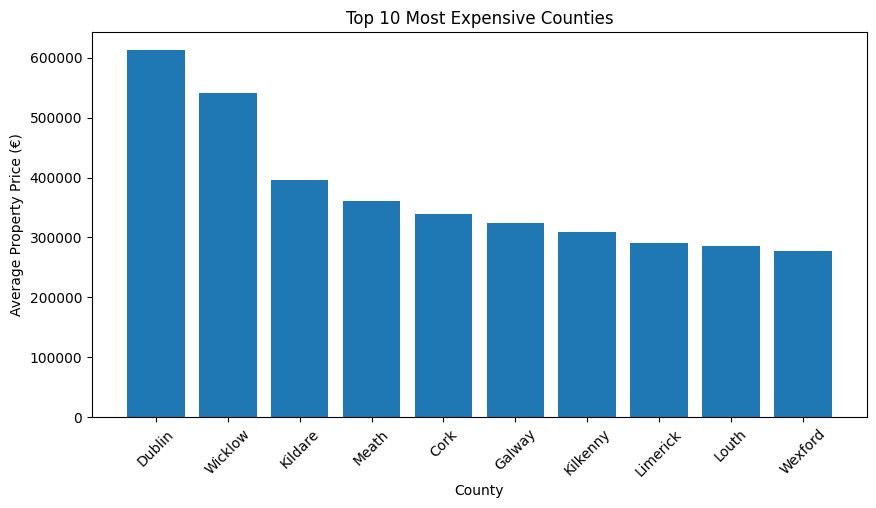

In [ ]:
top10 = county_prices.sort_values(by="avg_property_price",ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top10["county"], top10["avg_property_price"])

plt.title("Top 10 Most Expensive Counties")
plt.xlabel("County")
plt.ylabel("Average Property Price (€)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Number of sales by county
sales_count = property_df.groupby("county").size().reset_index(name="total_sales")

sales_count.head()

,county,total_sales
0,Carlow,8609
1,Cavan,11672
2,Clare,17646
3,Cork,87152
4,Donegal,20880


In [ ]:
sales_count.sort_values( by="total_sales", ascending=False).head(10)

,county,total_sales
5,Dublin,246278
3,Cork,87152
8,Kildare,42788
6,Galway,38059
16,Meath,32778
12,Limerick,28924
24,Wexford,27508
25,Wicklow,26615
14,Louth,22023
22,Waterford,21562


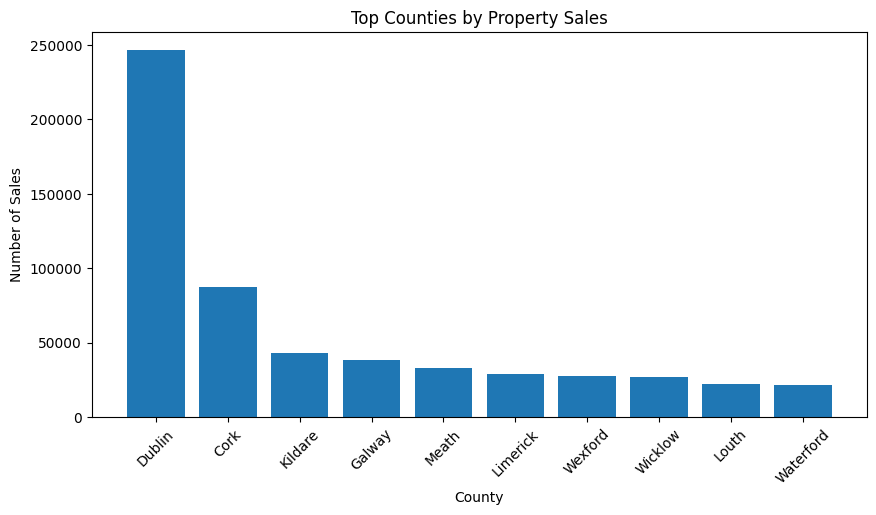

In [ ]:
# Which counties have the highest property market activity?

top_sales = sales_count.sort_values(by="total_sales",ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_sales["county"],top_sales["total_sales"])

plt.title("Top Counties by Property Sales")
plt.xlabel("County")
plt.ylabel("Number of Sales")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# How have house prices changed since 2010?
yearly_prices = property_df.groupby("year")["price"].median().reset_index()
yearly_prices

,year,price
0,2010,202500.0
1,2011,170000.0
2,2012,150000.0
3,2013,140000.0
4,2014,150000.0
5,2015,162500.0
6,2016,183000.0
7,2017,210000.0
8,2018,226432.5
9,2019,235000.0


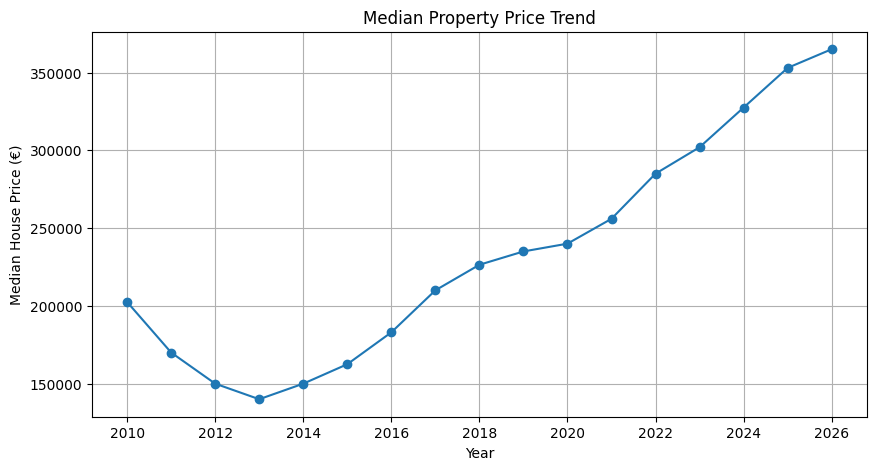

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_prices["year"],
    yearly_prices["price"],
    marker="o"
)

plt.title("Median Property Price Trend")
plt.xlabel("Year")
plt.ylabel("Median House Price (€)")

plt.grid(True)

plt.show()

##EDA earnings_df

In [ ]:
earnings_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 0 to 25
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   county              26 non-null     object 
 1   male_2022           26 non-null     float64
 2   male_2023           26 non-null     float64
 3   male_2024           26 non-null     float64
 4   female_2022         26 non-null     float64
 5   female_2023         26 non-null     float64
 6   female_2024         26 non-null     float64
 7   total_2022          26 non-null     float64
 8   total_2023          26 non-null     float64
 9   total_2024          26 non-null     float64
 10  annual_change_2023  26 non-null     float64
 11  annual_change_2024  26 non-null     float64
dtypes: float64(11), object(1)
memory usage: 2.6+ KB


In [ ]:
earnings_clean.describe(include="all")

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
count,26,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
unique,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Carlow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,710.825000,741.577692,774.795385,569.417308,597.036923,629.576923,643.235000,671.397308,704.821538,4.376923,5.019231
std,NaN,62.071948,65.548605,63.536717,40.255376,41.168015,40.363183,48.633141,51.275224,49.832641,0.577794,0.909074
min,NaN,587.020000,608.360000,648.910000,488.460000,520.030000,555.300000,540.000000,567.040000,603.670000,2.900000,3.000000
25%,NaN,667.032500,694.200000,729.880000,542.407500,572.590000,607.760000,616.552500,637.662500,670.750000,4.100000,4.600000
50%,NaN,702.945000,733.705000,766.680000,574.385000,596.060000,628.225000,634.960000,662.830000,697.230000,4.450000,5.150000
75%,NaN,733.887500,766.085000,794.865000,595.997500,623.112500,657.325000,664.682500,690.395000,726.577500,4.775000,5.600000


In [ ]:
earnings_clean.isnull().sum()

,0
county,0
male_2022,0
male_2023,0
male_2024,0
female_2022,0
female_2023,0
female_2024,0
total_2022,0
total_2023,0
total_2024,0


In [ ]:
earnings_clean.duplicated().sum()

np.int64(0)

In [ ]:
#Top counties by earning
earnings_clean.sort_values(by="total_2024",ascending=False)[["county","total_2024"]].head(10)

,county,total_2024
5,Dublin,821.42
8,Kildare,797.73
3,Cork,765.64
16,Meath,765.61
25,Wicklow,755.06
12,Limerick,740.95
6,Galway,728.49
23,Westmeath,720.84
10,Laois,720.02
2,Clare,718.22


In [ ]:
earnings_clean.sort_values(
    by="total_2024",
    ascending=True
)[["county","total_2024"]].head(10)

,county,total_2024
4,Donegal,603.67
7,Kerry,634.62
17,Monaghan,646.50
24,Wexford,653.41
13,Longford,663.86
15,Mayo,668.01
11,Leitrim,668.41
0,Carlow,677.77
1,Cavan,682.62
21,Tipperary,692.47


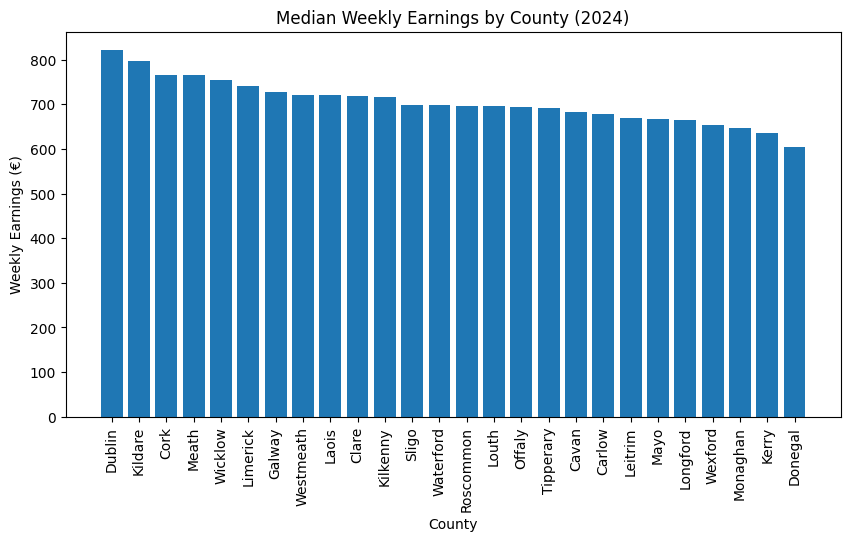

In [ ]:
import matplotlib.pyplot as plt

top_earnings = earnings_clean.sort_values(
    by="total_2024",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    top_earnings["county"],
    top_earnings["total_2024"]
)

plt.xticks(rotation=90)

plt.title("Median Weekly Earnings by County (2024)")
plt.xlabel("County")
plt.ylabel("Weekly Earnings (€)")

plt.show()

In [ ]:
earnings_clean[[
    "male_2024",
    "female_2024"
]].mean()

,0
male_2024,774.795385
female_2024,629.576923


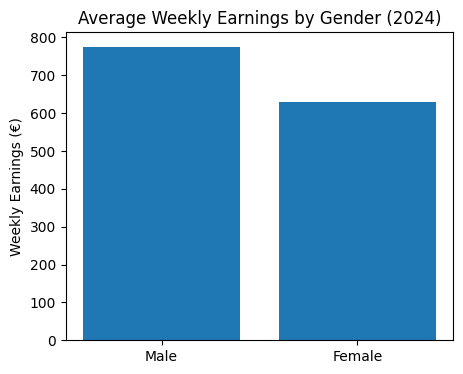

In [ ]:
gender_avg = [earnings_clean["male_2024"].mean(),earnings_clean["female_2024"].mean()]

plt.figure(figsize=(5,4))

plt.bar(["Male","Female"],gender_avg)

plt.title("Average Weekly Earnings by Gender (2024)")
plt.ylabel("Weekly Earnings (€)")

plt.show()

## EDA Population_clean

In [ ]:
population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   county             26 non-null     object 
 1   population_2022    26 non-null     int64  
 2   population_2016    26 non-null     int64  
 3   change_pct         26 non-null     float64
 4   population_growth  26 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.1+ KB


In [ ]:
population_df.describe(include="all")

,county,population_2022,population_2016,change_pct,population_growth
count,26,2.600000e+01,2.600000e+01,26.000000,26.000000
unique,26,NaN,NaN,NaN,NaN
top,Carlow,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,1.968071e+05,1.836539e+05,6.988462,13153.192308
std,NaN,2.781859e+05,2.577113e+05,3.313286,21287.192604
min,NaN,3.519900e+04,3.204400e+04,1.700000,1912.000000
25%,NaN,8.106975e+04,7.662225e+04,5.050000,4358.500000
50%,NaN,1.340890e+05,1.257710e+05,6.250000,6470.500000
75%,NaN,1.703538e+05,1.657192e+05,8.425000,12526.750000


In [ ]:
population_df.isnull().sum()

,0
county,0
population_2022,0
population_2016,0
change_pct,0
population_growth,0


In [ ]:
population_df.duplicated().sum()

np.int64(0)

In [ ]:
# Highest Population Counties
population_df.sort_values(by="population_2022",ascending=False).head(10)

,county,population_2022,population_2016,change_pct,population_growth
5,Dublin,1458154,1347359,8.2,110795
3,Cork,564696,542868,4.0,21828
6,Galway,284322,258058,10.2,26264
8,Kildare,246977,222504,11.0,24473
16,Meath,220928,195044,13.3,25884
12,Limerick,208081,194899,6.8,13182
21,Tipperary,170806,167895,1.7,2911
4,Donegal,168997,159192,6.2,9805
7,Kerry,158268,147707,7.1,10561
24,Wexford,157216,149722,5.0,7494


In [ ]:
# Fastest Growing Counties
population_df.sort_values(by="change_pct",ascending=False).head(10)

,county,population_2022,population_2016,change_pct,population_growth
13,Longford,46634,40873,14.1,5761
16,Meath,220928,195044,13.3,25884
14,Louth,145655,128884,13.0,16771
8,Kildare,246977,222504,11.0,24473
6,Galway,284322,258058,10.2,26264
11,Leitrim,35199,32044,9.8,3155
19,Roscommon,70000,64544,8.5,5456
5,Dublin,1458154,1347359,8.2,110795
0,Carlow,63339,58813,7.7,4526
10,Laois,91087,84697,7.5,6390


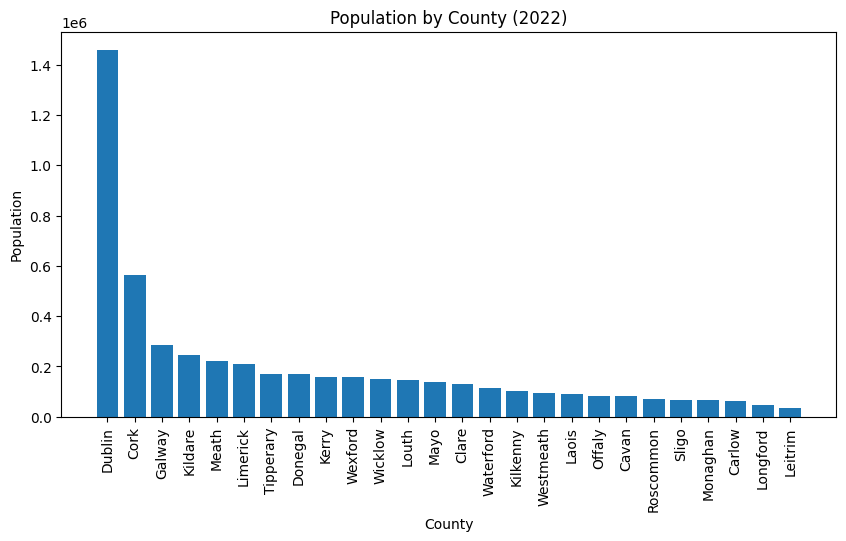

In [ ]:
top_pop = population_df.sort_values(
    by="population_2022",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    top_pop["county"],
    top_pop["population_2022"]
)

plt.xticks(rotation=90)

plt.title("Population by County (2022)")
plt.xlabel("County")
plt.ylabel("Population")

plt.show()

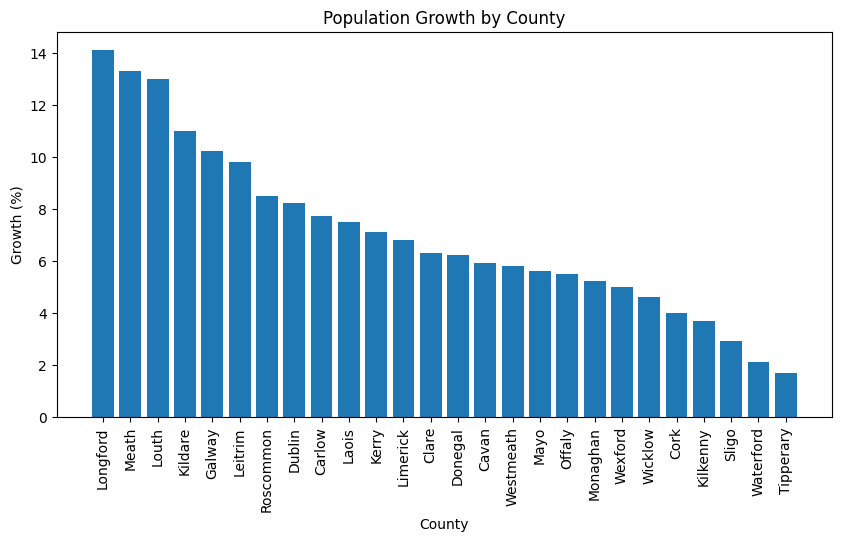

In [ ]:
growth = population_df.sort_values(
    by="change_pct",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    growth["county"],
    growth["change_pct"]
)

plt.xticks(rotation=90)

plt.title("Population Growth by County")
plt.xlabel("County")
plt.ylabel("Growth (%)")

plt.show()

# Merging Data

In [ ]:
# Filter to 2022-2024 to match earnings data year
# This is the correct approach — same time period for both datasets

property_recent = property_df[property_df['year'].between(2022, 2024)]
county_price = (
    property_recent
    .groupby("county")["price"]
    .mean()
    .reset_index()
)

county_price.columns = ["county", "avg_house_price"]

county_price.head(30)

,county,avg_house_price
0,Carlow,245534.877834
1,Cavan,212269.226866
2,Clare,268347.502073
3,Cork,339725.424571
4,Donegal,191492.638017
5,Dublin,612168.043185
6,Galway,324091.639949
7,Kerry,265996.081618
8,Kildare,395989.375458
9,Kilkenny,308983.782659


In [ ]:
earnings_clean.tail()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024
21,Tipperary,688.14,721.09,757.66,551.81,579.90,617.56,624.20,654.71,692.47,4.9,5.8
22,Waterford,714.49,746.72,781.01,541.63,576.92,609.85,632.42,661.96,697.34,4.7,5.3
23,Westmeath,726.71,760.00,793.01,576.14,602.39,636.92,654.69,682.46,720.84,4.2,5.6
24,Wexford,660.26,692.31,720.41,519.21,550.38,578.55,592.89,624.18,653.41,5.3,4.7
25,Wicklow,794.72,831.99,854.50,602.70,631.14,659.38,696.59,730.77,755.06,4.9,3.3


In [ ]:
# Remove national total row

earnings_clean = earnings_clean[
    earnings_clean["county"] != "Total3"
]

print(earnings_clean.shape)

(26, 12)


In [ ]:
# Creating Annual income
earnings_clean["annual_income"] = earnings_clean["total_2024"] * 52

earnings_clean.head()

,county,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024,annual_income
0,Carlow,701.65,719.95,750.07,529.73,557.37,590.29,625.00,646.79,677.77,3.5,4.8,35244.04
1,Cavan,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,682.62,4.3,5.4,35496.24
2,Clare,725.42,761.00,794.79,593.50,612.76,644.46,659.86,687.03,718.22,4.1,4.5,37347.44
3,Cork,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,765.64,4.6,5.4,39813.28
4,Donegal,587.02,608.36,648.91,488.46,520.03,555.30,540.00,567.04,603.67,5.0,6.5,31390.84


In [ ]:
# Merging House Prices and Earnings

merged_df = pd.merge(
    county_price,
    earnings_clean,
    on="county",
    how="inner"
)

merged_df.head()

,county,avg_house_price,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024,annual_income
0,Carlow,245534.877834,701.65,719.95,750.07,529.73,557.37,590.29,625.00,646.79,677.77,3.5,4.8,35244.04
1,Cavan,212269.226866,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,682.62,4.3,5.4,35496.24
2,Clare,268347.502073,725.42,761.00,794.79,593.50,612.76,644.46,659.86,687.03,718.22,4.1,4.5,37347.44
3,Cork,339725.424571,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,765.64,4.6,5.4,39813.28
4,Donegal,191492.638017,587.02,608.36,648.91,488.46,520.03,555.30,540.00,567.04,603.67,5.0,6.5,31390.84


In [ ]:
# Merging Population

merged_df = pd.merge(
    merged_df,
    population_df,
    on="county",
    how="inner"
)

merged_df.head(30)

,county,avg_house_price,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,total_2024,annual_change_2023,annual_change_2024,annual_income,population_2022,population_2016,change_pct,population_growth
0,Carlow,245534.877834,701.65,719.95,750.07,529.73,557.37,590.29,625.00,646.79,677.77,3.5,4.8,35244.04,63339,58813,7.7,4526
1,Cavan,212269.226866,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,682.62,4.3,5.4,35496.24,80668,76176,5.9,4492
2,Clare,268347.502073,725.42,761.00,794.79,593.50,612.76,644.46,659.86,687.03,718.22,4.1,4.5,37347.44,130392,122658,6.3,7734
3,Cork,339725.424571,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,765.64,4.6,5.4,39813.28,564696,542868,4.0,21828
4,Donegal,191492.638017,587.02,608.36,648.91,488.46,520.03,555.30,540.00,567.04,603.67,5.0,6.5,31390.84,168997,159192,6.2,9805
5,Dublin,612168.043185,835.05,874.52,904.71,672.22,709.75,736.09,757.03,793.71,821.42,4.8,3.5,42713.84,1458154,1347359,8.2,110795
6,Galway,324091.639949,719.58,746.40,783.21,610.35,633.52,670.20,666.29,690.97,728.49,3.7,5.4,37881.48,284322,258058,10.2,26264
7,Kerry,265996.081618,651.13,677.04,707.00,515.09,537.95,565.39,583.61,604.57,634.62,3.6,5.0,33000.24,158268,147707,7.1,10561
8,Kildare,395989.375458,832.29,865.83,900.35,627.24,660.92,692.28,733.52,766.19,797.73,4.5,4.1,41481.96,246977,222504,11.0,24473
9,Kilkenny,308983.782659,713.88,749.81,777.49,587.70,618.98,648.95,655.13,687.47,716.28,4.9,4.2,37246.56,102895,99232,3.7,3663


In [ ]:
merged_df.isnull().sum()

,0
county,0
avg_house_price,0
male_2022,0
male_2023,0
male_2024,0
female_2022,0
female_2023,0
female_2024,0
total_2022,0
total_2023,0


In [ ]:
merged_df.duplicated().sum()

np.int64(0)

In [ ]:
# Creating Affordability Ratio

merged_df["affordability_ratio"] = (merged_df["avg_house_price"] / merged_df["annual_income"])

In [ ]:
# Ranking Counties
merged_df.sort_values(
    by="affordability_ratio",
    ascending=False
)[["county","affordability_ratio"]]

,county,affordability_ratio
5,Dublin,14.331843
25,Wicklow,13.792844
8,Kildare,9.546062
16,Meath,9.078399
6,Galway,8.555411
3,Cork,8.532968
9,Kilkenny,8.295633
24,Wexford,8.140110
7,Kerry,8.060429
14,Louth,7.892031


<Figure size 1200x600 with 0 Axes>

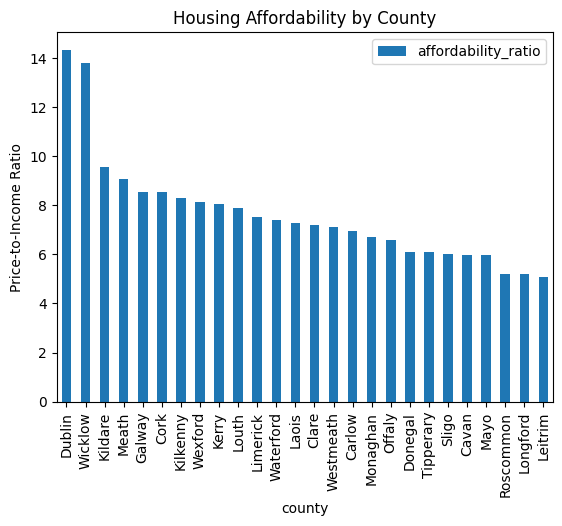

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

merged_df.sort_values(
    by="affordability_ratio",
    ascending=False
).plot(
    x="county",
    y="affordability_ratio",
    kind="bar"
)

plt.title("Housing Affordability by County")
plt.ylabel("Price-to-Income Ratio")

plt.show()

In [ ]:
# Correlation Analysis
merged_df[
    [
        "avg_house_price",
        "annual_income",
        "population_2022",
        "change_pct",
        "affordability_ratio"
    ]
].corr()

,avg_house_price,annual_income,population_2022,change_pct,affordability_ratio
avg_house_price,1.000000,0.786810,0.733042,0.063657,0.988584
annual_income,0.786810,1.000000,0.607319,0.152975,0.694092
population_2022,0.733042,0.607319,1.000000,0.054339,0.688066
change_pct,0.063657,0.152975,0.054339,1.000000,0.028552
affordability_ratio,0.988584,0.694092,0.688066,0.028552,1.000000


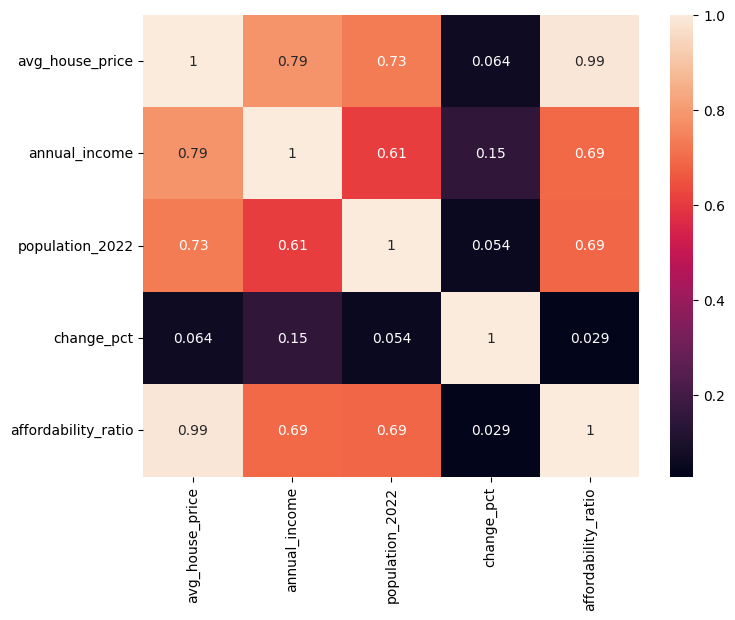

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    merged_df[
        [
            "avg_house_price",
            "annual_income",
            "population_2022",
            "change_pct",
            "affordability_ratio"
        ]
    ].corr(),
    annot=True
)

plt.show()

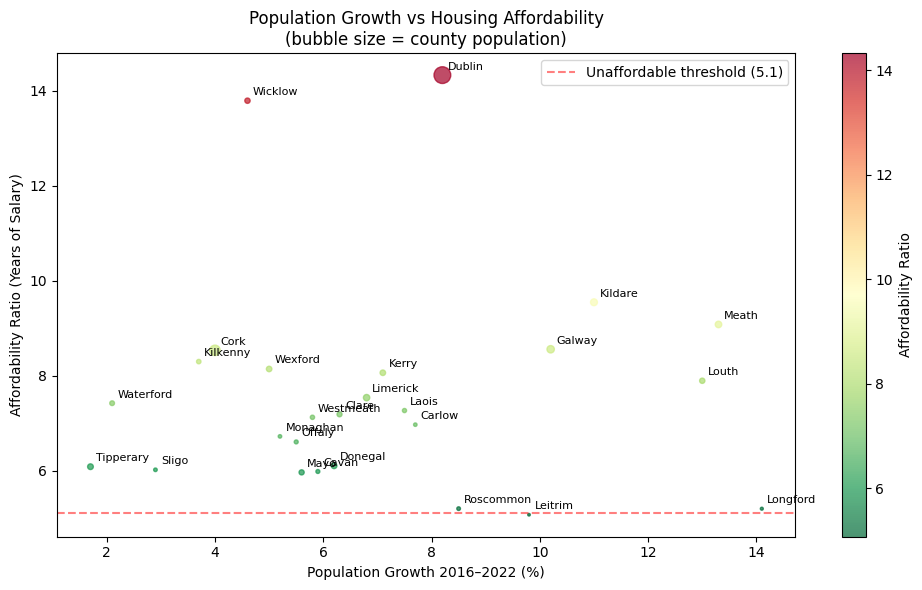

Correlation between population growth and affordability: 0.029

Key insight: Fast-growing commuter counties (Meath, Kildare, Louth) show both high population growth AND high affordability pressure


In [ ]:
# Population growth vs Affordability
# Does faster population growth mean worse affordability?

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    merged_df['change_pct'],
    merged_df['affordability_ratio'],
    s=merged_df['population_2022'] / 10000,
    alpha=0.7,
    c=merged_df['affordability_ratio'],
    cmap='RdYlGn_r'
)

# Label each county
for _, row in merged_df.iterrows():
    plt.annotate(
        row['county'],
        (row['change_pct'], row['affordability_ratio']),
        fontsize=8,
        xytext=(4, 4),
        textcoords='offset points'
    )

plt.axhline(y=5.1, color='red', linestyle='--',
            alpha=0.5, label='Unaffordable threshold (5.1)')
plt.xlabel('Population Growth 2016–2022 (%)')
plt.ylabel('Affordability Ratio (Years of Salary)')
plt.title('Population Growth vs Housing Affordability\n'
          '(bubble size = county population)')
plt.colorbar(scatter, label='Affordability Ratio')
plt.legend()
plt.tight_layout()
plt.show()

# Print the finding
correlation = merged_df['change_pct'].corr(
    merged_df['affordability_ratio'])
print(f"Correlation between population growth "
      f"and affordability: {correlation:.3f}")
print("\nKey insight: Fast-growing commuter counties "
      "(Meath, Kildare, Louth) show both high population "
      "growth AND high affordability pressure")

# Machine Learning Regression

In [ ]:
# Input Feautures
X = merged_df[
    [
        "annual_income",
        "population_2022",
        "change_pct"
    ]
]

In [ ]:
# Target
y = merged_df["avg_house_price"]

In [ ]:
# Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20, 3)
(6, 3)
(20,)
(6,)


In [ ]:
# Training Model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make Predictions
#Predicts house prices for counties in the test set

y_pred = lr.predict(X_test)
print(y_pred)

[392842.32125346 350933.85450398 229759.55117053 217049.51490473
 213772.74401085 281878.84938604]


In [ ]:
# Evaluating Model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 25607.193182415416
RMSE: 31782.019093436316
R2 Score: 0.808854818141037


In [ ]:
#Shows which variable influences house prices most

#Example findings:

#Income strongly affects prices
#Population growth affects prices
#Population size affects prices

#Very useful for report discussion.

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

importance_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,annual_income,22.075079
1,population_2022,0.147541
2,change_pct,-519.349581


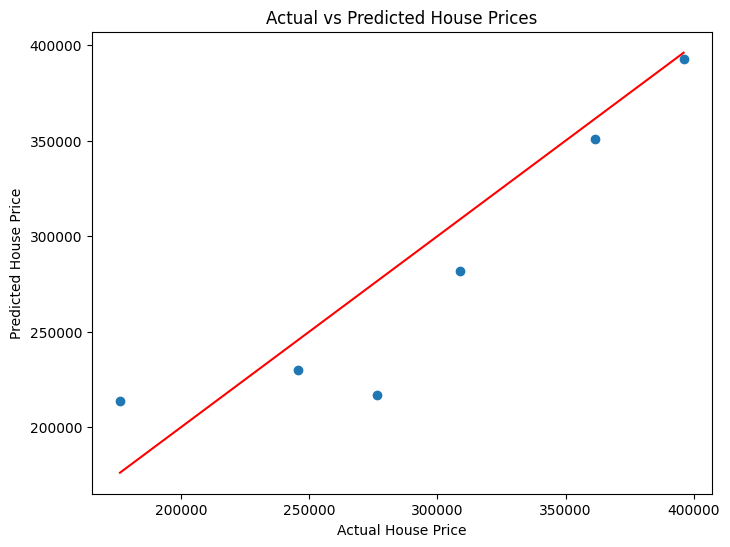

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

In [ ]:
# Feature importance

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df

,Feature,Coefficient
0,annual_income,22.075079
1,population_2022,0.147541
2,change_pct,-519.349581


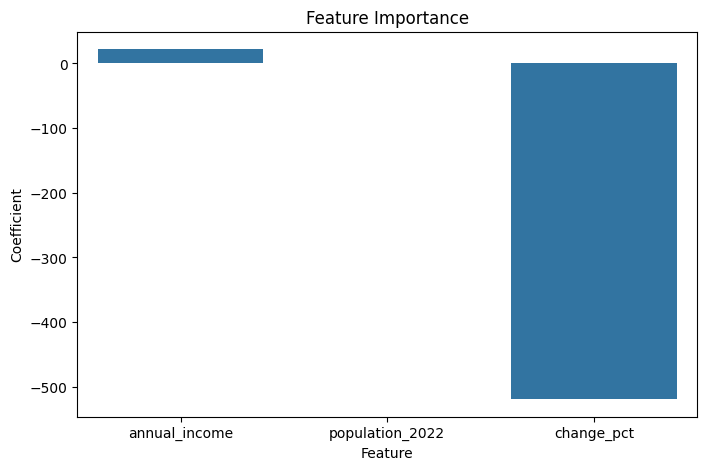

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=coef_df,
    x="Feature",
    y="Coefficient"
)

plt.title("Feature Importance")
plt.show()

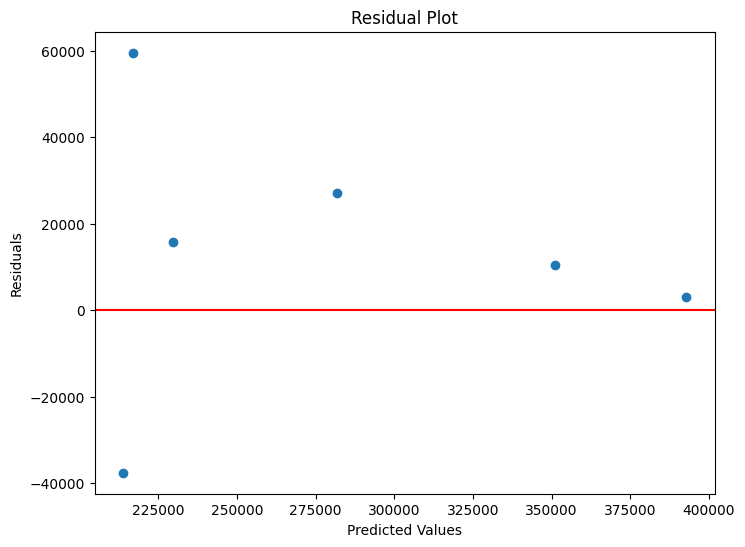

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

=== RANDOM FOREST RESULTS ===
R² Score : 0.1381
MAE      : €59,399
RMSE     : €67,486

Feature Importance:
           Feature  Importance
0    annual_income    0.746748
1  population_2022    0.162718
2       change_pct    0.090534


/tmp/ipykernel_21644/2431021959.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Feature', y='Importance', palette='viridis')


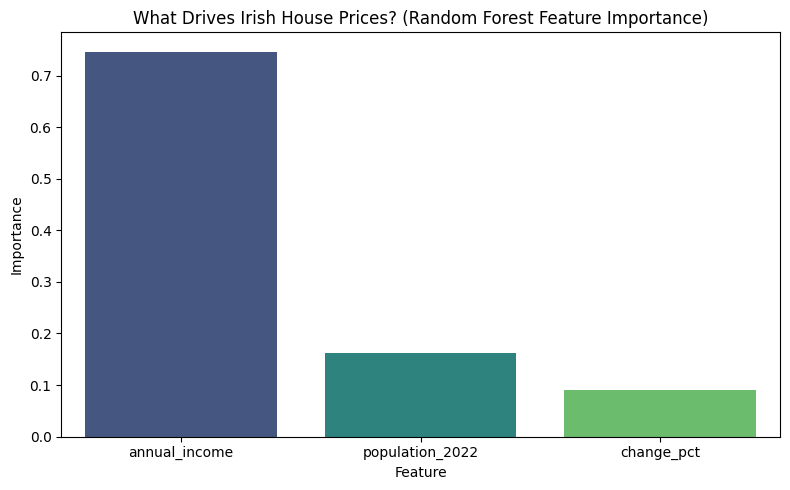

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST RESULTS ===")
print(f"R² Score : {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE      : €{mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE     : €{mean_squared_error(y_test, y_pred_rf)**0.5:,.0f}")

# Feature importance — your most impressive output
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(fi_df)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(data=fi_df, x='Feature', y='Importance', palette='viridis')
plt.title('What Drives Irish House Prices? (Random Forest Feature Importance)')
plt.tight_layout()
plt.show()

# K Means Clustering

## K-Means Clustering Analysis

K-Means clustering was applied to group Irish counties
based on average house price, annual income, and
housing affordability ratio.

The Elbow Method indicated that three clusters
provided the optimal grouping structure.

The resulting clusters represent:

• High Affordability Counties
• Moderate Affordability Counties
• Low Affordability Counties

This analysis helps identify regional differences
in housing affordability across Ireland.

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   county               26 non-null     object 
 1   avg_house_price      26 non-null     float64
 2   male_2022            26 non-null     float64
 3   male_2023            26 non-null     float64
 4   male_2024            26 non-null     float64
 5   female_2022          26 non-null     float64
 6   female_2023          26 non-null     float64
 7   female_2024          26 non-null     float64
 8   total_2022           26 non-null     float64
 9   total_2023           26 non-null     float64
 10  total_2024           26 non-null     float64
 11  annual_change_2023   26 non-null     float64
 12  annual_change_2024   26 non-null     float64
 13  annual_income        26 non-null     float64
 14  population_2022      26 non-null     int64  
 15  population_2016      26 non-null     int64

In [ ]:
cluster_features = merged_df[
    [
        "avg_house_price",
        "annual_income",
        "affordability_ratio"
    ]
]

cluster_features.head()

,avg_house_price,annual_income,affordability_ratio
0,245534.877834,35244.04,6.966706
1,212269.226866,35496.24,5.980048
2,268347.502073,37347.44,7.185165
3,339725.424571,39813.28,8.532968
4,191492.638017,31390.84,6.100271


In [ ]:
#Standardize the Data

#K-Means requires scaling because:

#House prices are in hundreds of thousands
#Income is in tens of thousands
#Population is in millions

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

scaled_features[:5]

array([[-0.37920151, -0.55359828, -0.30650548],
       [-0.7080755 , -0.45434508, -0.75557918],
       [-0.15366921,  0.27419384, -0.20707507],
       [ 0.55199389,  1.24462407,  0.40637231],
       [-0.91347896, -2.07002341, -0.70086014]])

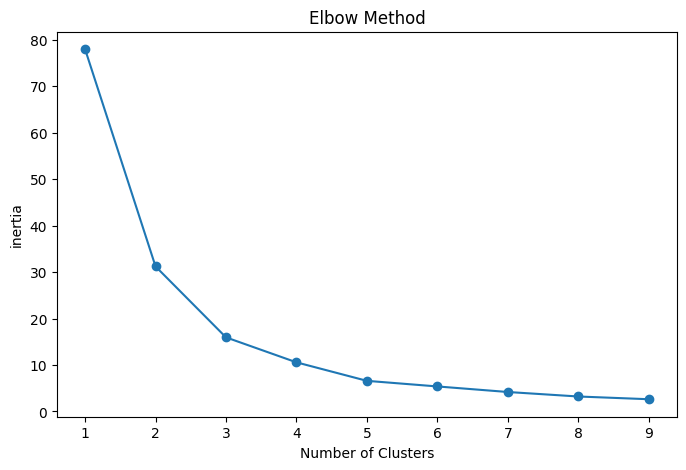

In [ ]:
# Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for i in range(1,10):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,10), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("inertia")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

merged_df["cluster"] = kmeans.fit_predict(
    scaled_features
)

In [ ]:
merged_df[
    [
        "county",
        "cluster",
        "avg_house_price",
        "annual_income",
        "affordability_ratio"
    ]
].sort_values("cluster")

,county,cluster,avg_house_price,annual_income,affordability_ratio
3,Cork,0,339725.424571,39813.28,8.532968
2,Clare,0,268347.502073,37347.44,7.185165
6,Galway,0,324091.639949,37881.48,8.555411
14,Louth,0,285886.919826,36224.76,7.892031
12,Limerick,0,290370.294760,38529.40,7.536331
10,Laois,0,271980.441193,37441.04,7.264233
9,Kilkenny,0,308983.782659,37246.56,8.295633
8,Kildare,0,395989.375458,41481.96,9.546062
23,Westmeath,0,266951.201693,37483.68,7.121798
16,Meath,0,361426.684084,39811.72,9.078399


In [ ]:
cluster_summary = merged_df.groupby("cluster")[
    [
        "avg_house_price",
        "annual_income",
        "affordability_ratio"
    ]
].mean()

cluster_summary

,avg_house_price,annual_income,affordability_ratio
cluster,,,
0,311375.326627,38326.132000,8.100803
1,222407.063169,34834.317143,6.393616
2,576859.057545,40988.480000,14.062343


In [ ]:
cluster_names = {
    0: "Moderate Affordability",
    1: "High Affordability",
    2: "Low Affordability",

}

merged_df["affordability_tier"] = (
    merged_df["cluster"]
    .map(cluster_names)
)

In [ ]:
merged_df[
    [
        "county",
        "cluster",
        "affordability_tier",
        "avg_house_price",
        "affordability_ratio"
    ]
].sort_values(
    by="affordability_ratio",
    ascending=False
)

,county,cluster,affordability_tier,avg_house_price,affordability_ratio
5,Dublin,2,Low Affordability,612168.043185,14.331843
25,Wicklow,2,Low Affordability,541550.071906,13.792844
8,Kildare,0,Moderate Affordability,395989.375458,9.546062
16,Meath,0,Moderate Affordability,361426.684084,9.078399
6,Galway,0,Moderate Affordability,324091.639949,8.555411
3,Cork,0,Moderate Affordability,339725.424571,8.532968
9,Kilkenny,0,Moderate Affordability,308983.782659,8.295633
24,Wexford,1,High Affordability,276579.126497,8.140110
7,Kerry,1,High Affordability,265996.081618,8.060429
14,Louth,0,Moderate Affordability,285886.919826,7.892031


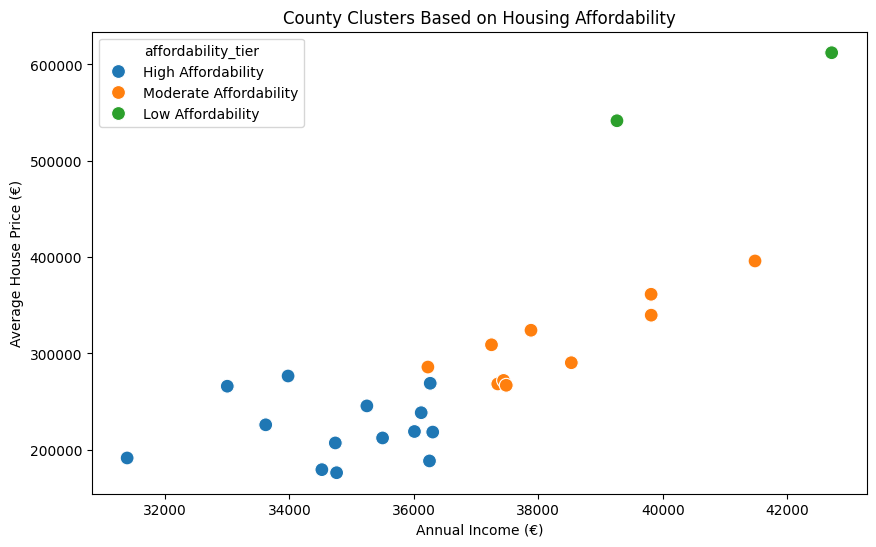

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="annual_income",
    y="avg_house_price",
    hue="affordability_tier",
    s=100
)

plt.title("County Clusters Based on Housing Affordability")

plt.xlabel("Annual Income (€)")
plt.ylabel("Average House Price (€)")

plt.show()

In [ ]:
merged_df["affordability_tier"].value_counts()

,count
affordability_tier,
High Affordability,14
Moderate Affordability,10
Low Affordability,2


# Download Merged Data

In [ ]:
merged_df.to_csv("irish_housing_final.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


In [ ]:
new=pd.read_csv("/content/irish_housing_final.csv")

In [ ]:
new.head()

,county,avg_house_price,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,...,annual_change_2023,annual_change_2024,annual_income,population_2022,population_2016,change_pct,population_growth,affordability_ratio,cluster,affordability_tier
0,Carlow,245534.877834,701.65,719.95,750.07,529.73,557.37,590.29,625.00,646.79,...,3.5,4.8,35244.04,63339,58813,7.7,4526,6.966706,1,High Affordability
1,Cavan,212269.226866,686.84,714.86,750.92,544.38,574.54,607.59,620.97,647.57,...,4.3,5.4,35496.24,80668,76176,5.9,4492,5.980048,1,High Affordability
2,Clare,268347.502073,725.42,761.00,794.79,593.50,612.76,644.46,659.86,687.03,...,4.1,4.5,37347.44,130392,122658,6.3,7734,7.185165,0,Moderate Affordability
3,Cork,339725.424571,795.88,830.85,871.35,593.38,624.49,657.75,694.96,726.74,...,4.6,5.4,39813.28,564696,542868,4.0,21828,8.532968,0,Moderate Affordability
4,Donegal,191492.638017,587.02,608.36,648.91,488.46,520.03,555.30,540.00,567.04,...,5.0,6.5,31390.84,168997,159192,6.2,9805,6.100271,1,High Affordability


In [ ]:
new.tail()

,county,avg_house_price,male_2022,male_2023,male_2024,female_2022,female_2023,female_2024,total_2022,total_2023,...,annual_change_2023,annual_change_2024,annual_income,population_2022,population_2016,change_pct,population_growth,affordability_ratio,cluster,affordability_tier
21,Tipperary,218973.718194,688.14,721.09,757.66,551.81,579.90,617.56,624.20,654.71,...,4.9,5.8,36008.44,170806,167895,1.7,2911,6.081178,1,High Affordability
22,Waterford,269027.313561,714.49,746.72,781.01,541.63,576.92,609.85,632.42,661.96,...,4.7,5.3,36261.68,116176,113795,2.1,2381,7.419053,1,High Affordability
23,Westmeath,266951.201693,726.71,760.00,793.01,576.14,602.39,636.92,654.69,682.46,...,4.2,5.6,37483.68,95419,90223,5.8,5196,7.121798,0,Moderate Affordability
24,Wexford,276579.126497,660.26,692.31,720.41,519.21,550.38,578.55,592.89,624.18,...,5.3,4.7,33977.32,157216,149722,5.0,7494,8.140110,1,High Affordability
25,Wicklow,541550.071906,794.72,831.99,854.50,602.70,631.14,659.38,696.59,730.77,...,4.9,3.3,39263.12,148976,142425,4.6,6551,13.792844,2,Low Affordability
